# Module Nine Project

For the module nine project you are required to produce coding samples in accordance with the requirements in the project guidelines and rubric. This Notebook has been pre-created as a shell for your project submission.

Once your code is complete, you will download this notebook as an HTML file by clicking **File**, then **Download As**, then **HTML (.html)** from the Jupyter menu bar. Validate that your code and outputs are rendered in the html file before submission.

<div class="alert alert-block alert-danger">
    <span style="color:black"><b><i>Missing Blocks:</i></b> Ensure that you have clicked <b><mark>Run</mark></b> for all blocks before downloading as an HTML file or the block may be missing from your submission.</span>
</div>

### Data Source Information
Below are some example reputable data sources that you can use to collect your minimum of two data sets from:

- https://datasetsearch.research.google.com/
- https://www.kaggle.com/datasets
- https://data.gov/
- https://www.census.gov/data.html
- https://www.bls.gov/data/
- https://databank.worldbank.org/databases
- https://www.ncei.noaa.gov/access/search/index
- https://www.epa.gov/data
- https://www.pewresearch.org/tools-and-datasets/
- https://www.who.int/data/
- https://dataverse.harvard.edu/
- https://search.cdc.gov/search/?query=dataset&dpage=1
- https://data.fivethirtyeight.com/
- https://www.gdeltproject.org/data.html
- https://datahub.io/collections


***Note: this list is not all inclusive, if you have a reputable data set that you have collected, or would like to use, please ensure to upload the data. All data sets will need to be documented in your submission as to the source through the creation of a citation.***

<div class="alert alert-block alert-success">
    <span style="color:black"><b><i>To Begin:</i></b> replace each <b>data_file_#</b> entry sample data path with the path to your selected data sets.</span>
</div>

You are welcome to use more than two data sets, create an entry for each as applicable for each data set. Ensure that you create comments that provide citations for the data sets you have selected for use. When working through your submission, keep in mind that you will need to have choosen two separate groups of stakeholders to create your final visualizations.

In [20]:
# Source 1:
# USDA Economic Research Service, Population Estimates for the
# United States, States, and Counties, 2020–2023.
# https://www.ers.usda.gov/data-products/county-level-data-sets/

data_file_1 = "data/PopulationEstimates.csv"

# Source 2:
# USDA Economic Research Service, Unemployment and Median Household
# Income for the United States, States, and Counties, 2000–2023.
# https://www.ers.usda.gov/data-products/county-level-data-sets/

data_file_2 = "data/Unemployment2023.csv"

## Installing Required Packages
If you have additional packages that you would like to use or install, add them to the **requirements.txt** file then run the next two blocks.

In [21]:
!pip install --upgrade pip

In [22]:
!pip install -r requirements.txt

## Import the Required Packages

In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Loading the Data
Create entries to load your data for your submission.

In [28]:
population_raw = pd.read_csv(
    data_file_1,
    encoding="latin1"
)

unemployment_raw = pd.read_csv(
    data_file_2,
    encoding="latin1"
)

print(
    "Population dataset shape:",
    population_raw.shape
)

print(
    "Unemployment dataset shape:",
    unemployment_raw.shape
)

print("\nPopulation sample:")
display(population_raw.head())

print("\nUnemployment sample:")
display(unemployment_raw.head())

Population dataset shape: (3238, 5)
Unemployment dataset shape: (1184, 5)

Population sample:


,FIPStxt,State,Area_Name,Attribute,Value
0,0,US,United States,CENSUS_2020_POP,331449281.0
1,0,US,United States,ESTIMATES_BASE_2020,331464948.0
2,0,US,United States,POP_ESTIMATE_2020,331526933.0
3,0,US,United States,POP_ESTIMATE_2021,332048977.0
4,0,US,United States,POP_ESTIMATE_2022,333271411.0



Unemployment sample:


,FIPS_Code,State,Area_Name,Attribute,Value
0,0,US,United States,Civilian_labor_force_2019,163815894.0
1,0,US,United States,Employed_2019,157805901.0
2,0,US,United States,Unemployed_2019,6009993.0
3,0,US,United States,Unemployment_rate_2019,3.7
4,0,US,United States,Civilian_labor_force_2020,161131754.0


## Examining the Data
Create entries to conduct exploratory data analysis to identify key data points to include relevant data from your two data sets while evaluating the quality of your choosen data.

In [29]:
quality_summary = pd.DataFrame(
    {
        "dataset": [
            "Population",
            "Unemployment"
        ],
        "rows": [
            len(population_raw),
            len(unemployment_raw)
        ],
        "columns": [
            population_raw.shape[1],
            unemployment_raw.shape[1]
        ],
        "missing_values": [
            population_raw.isna().sum().sum(),
            unemployment_raw.isna().sum().sum()
        ],
        "duplicate_rows": [
            population_raw.duplicated().sum(),
            unemployment_raw.duplicated().sum()
        ],
        "unique_areas": [
            population_raw["FIPStxt"].nunique(),
            unemployment_raw["FIPS_Code"].nunique()
        ]
    }
)

print("\nDATA QUALITY SUMMARY")
display(quality_summary)

print("\nPopulation column types:")
display(
    population_raw.dtypes.to_frame(
        "data_type"
    )
)

print("\nUnemployment column types:")
display(
    unemployment_raw.dtypes.to_frame(
        "data_type"
    )
)

print("\nPopulation attributes:")

print(
    population_raw["Attribute"]
    .dropna()
    .unique()
)

print("\nUnemployment attributes containing 2023:")

print(
    [
        attribute
        for attribute in unemployment_raw[
            "Attribute"
        ].dropna().unique()
        if "2023" in str(attribute)
    ]
)


DATA QUALITY SUMMARY


,dataset,rows,columns,missing_values,duplicate_rows,unique_areas
0,Population,3238,5,0,0,54
1,Unemployment,1184,5,0,0,54



Population column types:


,data_type
FIPStxt,int64
State,object
Area_Name,object
Attribute,object
Value,float64



Unemployment column types:


,data_type
FIPS_Code,int64
State,object
Area_Name,object
Attribute,object
Value,float64



Population attributes:
['CENSUS_2020_POP' 'ESTIMATES_BASE_2020' 'POP_ESTIMATE_2020'
 'POP_ESTIMATE_2021' 'POP_ESTIMATE_2022' 'POP_ESTIMATE_2023'
 'N_POP_CHG_2020' 'N_POP_CHG_2021' 'N_POP_CHG_2022' 'N_POP_CHG_2023'
 'BIRTHS_2020' 'BIRTHS_2021' 'BIRTHS_2022' 'BIRTHS_2023' 'DEATHS_2020'
 'DEATHS_2021' 'DEATHS_2022' 'DEATHS_2023' 'NATURAL_CHG_2020'
 'NATURAL_CHG_2021' 'NATURAL_CHG_2022' 'NATURAL_CHG_2023'
 'INTERNATIONAL_MIG_2020' 'INTERNATIONAL_MIG_2021'
 'INTERNATIONAL_MIG_2022' 'INTERNATIONAL_MIG_2023' 'DOMESTIC_MIG_2020'
 'DOMESTIC_MIG_2021' 'DOMESTIC_MIG_2022' 'DOMESTIC_MIG_2023'
 'NET_MIG_2020' 'NET_MIG_2021' 'NET_MIG_2022' 'NET_MIG_2023'
 'RESIDUAL_2020' 'RESIDUAL_2021' 'RESIDUAL_2022' 'RESIDUAL_2023'
 'R_BIRTH_2021' 'R_BIRTH_2022' 'R_BIRTH_2023' 'R_DEATH_2021'
 'R_DEATH_2022' 'R_DEATH_2023' 'R_NATURAL_CHG_2021' 'R_NATURAL_CHG_2022'
 'R_NATURAL_CHG_2023' 'R_INTERNATIONAL_MIG_2021'
 'R_INTERNATIONAL_MIG_2022' 'R_INTERNATIONAL_MIG_2023'
 'R_DOMESTIC_MIG_2021' 'R_DOMESTIC_MIG_2022' 'R

## Data Preprocessing Techniques
Create entries to clean and blend your data sets as applicable consolidating the two or more data sets into a single collection for inclusion into your visualizations.

In [32]:
from pathlib import Path
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# OFFICIAL DATASET SOURCES
# ============================================================

# United States Department of Agriculture, Economic Research Service.
# Population estimates for the United States, States, and counties,
# 2020–2023.
population_url = (
    "https://www.ers.usda.gov/media/5499/"
    "population-estimates-for-the-united-states-states-"
    "and-counties-2020-23.csv?v=10201"
)

# United States Department of Agriculture, Economic Research Service.
# Unemployment and median household income for the United States,
# States, and counties, 2000–2023.
unemployment_url = (
    "https://www.ers.usda.gov/media/5497/"
    "unemployment-and-median-household-income-for-the-"
    "united-states-states-and-counties-2000-23.csv?v=10097"
)


# ============================================================
# LOCATE OR DOWNLOAD THE FULL DATASETS
# ============================================================

data_directory = Path("data")
data_directory.mkdir(exist_ok=True)

population_download_path = (
    data_directory
    / "PopulationEstimates_full.csv"
)

unemployment_download_path = (
    data_directory
    / "Unemployment2023_full.csv"
)


def find_full_local_file(filename_start):
    matches = [
        path
        for path in Path(".").rglob("*")
        if path.is_file()
        and path.name.lower().startswith(
            filename_start.lower()
        )
        and path.suffix.lower() == ".csv"
        and "sample_use_only"
        not in str(path).lower()
    ]

    if not matches:
        return None

    # Select the largest matching file.
    # The complete dataset is substantially larger
    # than the course sample.
    return max(
        matches,
        key=lambda path: path.stat().st_size
    )


def download_file(url, destination):
    print(
        f"Downloading full dataset to {destination}..."
    )

    request = Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0"
        }
    )

    with urlopen(
        request,
        timeout=120
    ) as response:
        file_data = response.read()

    destination.write_bytes(file_data)

    print(
        f"Downloaded {len(file_data):,} bytes."
    )

    return destination


# Search for existing full files.
population_path = find_full_local_file(
    "PopulationEstimates"
)

unemployment_path = find_full_local_file(
    "Unemployment2023"
)


# Download population data if the full file is missing.
if (
    population_path is None
    or population_path.stat().st_size
    < 1_000_000
):
    population_path = download_file(
        population_url,
        population_download_path
    )


# Download unemployment data if the full file is missing.
if (
    unemployment_path is None
    or unemployment_path.stat().st_size
    < 1_000_000
):
    unemployment_path = download_file(
        unemployment_url,
        unemployment_download_path
    )


print(
    "Full population path:",
    population_path
)

print(
    "Full unemployment path:",
    unemployment_path
)


# ============================================================
# LOAD THE FULL DATASETS
# ============================================================

population_raw = pd.read_csv(
    population_path,
    encoding="latin1"
)

unemployment_raw = pd.read_csv(
    unemployment_path,
    encoding="latin1"
)

print(
    "Population source records:",
    f"{len(population_raw):,}"
)

print(
    "Unemployment source records:",
    f"{len(unemployment_raw):,}"
)


# Verify that full datasets were loaded.
if len(population_raw) < 100_000:
    raise ValueError(
        "The population dataset contains fewer than "
        "100,000 records and appears to be a sample."
    )

if len(unemployment_raw) < 100_000:
    raise ValueError(
        "The unemployment dataset contains fewer than "
        "100,000 records and appears to be a sample."
    )


print("\nPopulation sample:")
display(population_raw.head())

print("\nUnemployment sample:")
display(unemployment_raw.head())


# ============================================================
# EXAMINE SOURCE DATA QUALITY
# ============================================================

quality_summary = pd.DataFrame(
    {
        "dataset": [
            "Population",
            "Unemployment"
        ],
        "rows": [
            len(population_raw),
            len(unemployment_raw)
        ],
        "columns": [
            population_raw.shape[1],
            unemployment_raw.shape[1]
        ],
        "missing_values": [
            population_raw.isna().sum().sum(),
            unemployment_raw.isna().sum().sum()
        ],
        "duplicate_rows": [
            population_raw.duplicated().sum(),
            unemployment_raw.duplicated().sum()
        ],
        "unique_areas": [
            population_raw[
                "FIPStxt"
            ].nunique(),
            unemployment_raw[
                "FIPS_Code"
            ].nunique()
        ]
    }
)

print("\nSOURCE DATA QUALITY")

display(quality_summary)


# ============================================================
# STANDARDIZE THE POPULATION DATASET
# ============================================================

population = population_raw.rename(
    columns={
        "FIPStxt": "fips",
        "State": "state",
        "Area_Name": "area_name",
        "Attribute": "attribute",
        "Value": "value"
    }
).copy()


# ============================================================
# STANDARDIZE THE UNEMPLOYMENT DATASET
# ============================================================

unemployment = unemployment_raw.rename(
    columns={
        "FIPS_Code": "fips",
        "State": "state",
        "Area_Name": "area_name",
        "Attribute": "attribute",
        "Value": "value"
    }
).copy()


# ============================================================
# STANDARDIZE DATA TYPES AND TEXT
# ============================================================

for dataset in [
    population,
    unemployment
]:
    dataset["fips"] = pd.to_numeric(
        dataset["fips"],
        errors="coerce"
    )

    dataset["value"] = pd.to_numeric(
        dataset["value"],
        errors="coerce"
    )

    dataset["state"] = (
        dataset["state"]
        .astype("string")
        .str.strip()
    )

    dataset["area_name"] = (
        dataset["area_name"]
        .astype("string")
        .str.strip()
    )

    dataset["attribute"] = (
        dataset["attribute"]
        .astype("string")
        .str.strip()
    )

    dataset.dropna(
        subset=[
            "fips",
            "state",
            "area_name",
            "attribute"
        ],
        inplace=True
    )

    dataset["fips"] = (
        dataset["fips"]
        .astype(int)
    )

    dataset.drop_duplicates(
        subset=[
            "fips",
            "attribute"
        ],
        inplace=True
    )


# ============================================================
# KEEP COUNTY-LEVEL RECORDS
# ============================================================

# National records use FIPS 0.
# State-level records have shorter codes or
# codes ending in 000.

population_counties = population.loc[
    (population["fips"] >= 1000)
    &
    (population["fips"] % 1000 != 0)
].copy()

unemployment_counties = unemployment.loc[
    (unemployment["fips"] >= 1000)
    &
    (unemployment["fips"] % 1000 != 0)
].copy()

print(
    "\nCounty-level population records:",
    f"{len(population_counties):,}"
)

print(
    "County-level unemployment records:",
    f"{len(unemployment_counties):,}"
)

print(
    "Population county identifiers:",
    f"{population_counties['fips'].nunique():,}"
)

print(
    "Unemployment county identifiers:",
    f"{unemployment_counties['fips'].nunique():,}"
)


# ============================================================
# IDENTIFY THE LATEST COMMON YEAR
# ============================================================

population_years = set(
    population_counties["attribute"]
    .str.extract(
        r"^POP_ESTIMATE_(\d{4})$",
        expand=False
    )
    .dropna()
    .astype(int)
)

unemployment_years = set(
    unemployment_counties["attribute"]
    .str.extract(
        r"^Unemployment_rate_(\d{4})$",
        expand=False
    )
    .dropna()
    .astype(int)
)

common_years = sorted(
    population_years.intersection(
        unemployment_years
    )
)

if not common_years:
    raise ValueError(
        "No common year was found between the "
        "population and unemployment datasets."
    )

analysis_year = max(common_years)

print(
    "\nAvailable population years:",
    sorted(population_years)
)

print(
    "Latest unemployment year:",
    max(unemployment_years)
)

print(
    "Selected analysis year:",
    analysis_year
)


# ============================================================
# PREPARE THE POPULATION DATA
# ============================================================

population_attribute = (
    f"POP_ESTIMATE_{analysis_year}"
)

population_selected = population_counties.loc[
    population_counties["attribute"]
    == population_attribute,
    [
        "fips",
        "state",
        "area_name",
        "value"
    ]
].copy()

population_selected = population_selected.rename(
    columns={
        "value": "population"
    }
)

population_selected = (
    population_selected
    .drop_duplicates(
        subset=["fips"]
    )
)

print(
    "\nPrepared population records:",
    f"{len(population_selected):,}"
)


# ============================================================
# PREPARE THE UNEMPLOYMENT DATA
# ============================================================

unemployment_attributes = [
    f"Civilian_labor_force_{analysis_year}",
    f"Employed_{analysis_year}",
    f"Unemployed_{analysis_year}",
    f"Unemployment_rate_{analysis_year}"
]

unemployment_selected = unemployment_counties.loc[
    unemployment_counties["attribute"]
    .isin(unemployment_attributes)
].copy()


# Change the unemployment data from long to wide format.
unemployment_wide = (
    unemployment_selected
    .pivot_table(
        index=[
            "fips",
            "state",
            "area_name"
        ],
        columns="attribute",
        values="value",
        aggfunc="first"
    )
    .reset_index()
    .rename_axis(
        None,
        axis=1
    )
)

unemployment_wide = unemployment_wide.rename(
    columns={
        f"Civilian_labor_force_{analysis_year}":
            "labor_force",
        f"Employed_{analysis_year}":
            "employed",
        f"Unemployed_{analysis_year}":
            "unemployed",
        f"Unemployment_rate_{analysis_year}":
            "unemployment_rate"
    }
)

print(
    "Prepared unemployment records:",
    f"{len(unemployment_wide):,}"
)


# ============================================================
# EVALUATE UNMATCHED IDENTIFIERS
# ============================================================

population_fips = set(
    population_selected["fips"]
)

unemployment_fips = set(
    unemployment_wide["fips"]
)

population_only = (
    population_fips
    - unemployment_fips
)

unemployment_only = (
    unemployment_fips
    - population_fips
)

print(
    "\nPopulation counties without unemployment data:",
    len(population_only)
)

print(
    "Unemployment counties without population data:",
    len(unemployment_only)
)


# ============================================================
# BLEND THE DATASETS
# ============================================================

analysis = population_selected.merge(
    unemployment_wide,
    on="fips",
    how="inner",
    suffixes=(
        "_population",
        "_unemployment"
    ),
    validate="one_to_one"
)


# Consolidate state values.
analysis["state"] = (
    analysis["state_population"]
    .fillna(
        analysis["state_unemployment"]
    )
)


# Consolidate county names.
analysis["county"] = (
    analysis["area_name_population"]
    .fillna(
        analysis["area_name_unemployment"]
    )
)


# Keep the relevant analysis attributes.
analysis = analysis[
    [
        "fips",
        "state",
        "county",
        "population",
        "labor_force",
        "employed",
        "unemployed",
        "unemployment_rate"
    ]
].copy()


# ============================================================
# CLEAN THE INTEGRATED COLLECTION
# ============================================================

numeric_columns = [
    "population",
    "labor_force",
    "employed",
    "unemployed",
    "unemployment_rate"
]

for column in numeric_columns:
    analysis[column] = pd.to_numeric(
        analysis[column],
        errors="coerce"
    )


missing_before_cleaning = (
    analysis[numeric_columns]
    .isna()
    .sum()
)

print(
    "\nMissing values before final cleaning:"
)

display(
    missing_before_cleaning
    .to_frame("missing_count")
)


# Remove missing required values.
analysis.dropna(
    subset=[
        "population",
        "labor_force",
        "employed",
        "unemployed",
        "unemployment_rate"
    ],
    inplace=True
)


# Remove invalid values.
analysis = analysis.loc[
    (analysis["population"] > 0)
    &
    (analysis["labor_force"] > 0)
    &
    (analysis["employed"] >= 0)
    &
    (analysis["unemployed"] >= 0)
    &
    (
        analysis["unemployment_rate"]
        .between(0, 100)
    )
].copy()


# ============================================================
# VALIDATE UNEMPLOYMENT RATES
# ============================================================

analysis[
    "calculated_unemployment_rate"
] = (
    analysis["unemployed"]
    / analysis["labor_force"]
    * 100
)

analysis["rate_difference"] = abs(
    analysis["unemployment_rate"]
    - analysis[
        "calculated_unemployment_rate"
    ]
)


# ============================================================
# CREATE MULTI-LEVEL POPULATION GROUPS
# ============================================================

population_labels = [
    "Smallest counties",
    "Smaller counties",
    "Larger counties",
    "Largest counties"
]

population_rank = (
    analysis["population"]
    .rank(method="first")
)

analysis["population_group"] = pd.qcut(
    population_rank,
    q=4,
    labels=population_labels
)


# Create logarithmic population values.
analysis["log10_population"] = np.log10(
    analysis["population"]
)


# Sort the integrated collection.
analysis = (
    analysis
    .sort_values(
        [
            "state",
            "county"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# DISPLAY FINAL RESULTS
# ============================================================

print(
    "\nFINAL PREPROCESSING RESULTS"
)

print(
    "Population source records:",
    f"{len(population_raw):,}"
)

print(
    "Unemployment source records:",
    f"{len(unemployment_raw):,}"
)

print(
    "Final merged county records:",
    f"{len(analysis):,}"
)

print(
    "States and territories represented:",
    analysis["state"].nunique()
)

print(
    "Missing values in final collection:",
    analysis.isna().sum().sum()
)

print(
    "Duplicate FIPS codes:",
    analysis["fips"].duplicated().sum()
)

print(
    "Largest rate-check difference:",
    round(
        analysis["rate_difference"].max(),
        3
    )
)

print(
    "\nCounties in each population group:"
)

display(
    analysis["population_group"]
    .value_counts(sort=False)
    .to_frame("county_count")
)

print(
    "\nFinal integrated collection:"
)

display(
    analysis.head(10)
)


# ============================================================
# DATA QUALITY EVALUATION
# ============================================================

print(
    "\nDATA QUALITY EVALUATION\n"
    "The population and unemployment datasets use "
    "compatible county FIPS identifiers and a consistent "
    "long-data structure. National and state summary "
    "records were removed so the integrated collection "
    "contains one geographic level. Duplicate geographic "
    "attributes, missing measurements, invalid numeric "
    "values, and implausible unemployment rates were "
    "checked before analysis. Reported unemployment rates "
    "were compared with rates recalculated from unemployed "
    "residents and civilian labor-force totals. Small "
    "differences may result from rounding in the published "
    "data. The completed collection describes one year "
    "and supports cross-sectional comparisons, not causal "
    "conclusions or long-term trend claims."
)

Downloaded 9,624,467 bytes.
Downloaded 18,403,337 bytes.
Full population path: data/PopulationEstimates_full.csv
Full unemployment path: data/Unemployment2023_full.csv
Population source records: 208,225
Unemployment source records: 329,726

Population sample:


,FIPStxt,State,Area_Name,Attribute,Value
0,0,US,United States,CENSUS_2020_POP,331449281.0
1,0,US,United States,ESTIMATES_BASE_2020,331464948.0
2,0,US,United States,POP_ESTIMATE_2020,331526933.0
3,0,US,United States,POP_ESTIMATE_2021,332048977.0
4,0,US,United States,POP_ESTIMATE_2022,333271411.0



Unemployment sample:


,FIPS_Code,State,Area_Name,Attribute,Value
0,0,US,United States,Civilian_labor_force_2000,142601576.0
1,0,US,United States,Employed_2000,136904853.0
2,0,US,United States,Unemployed_2000,5696723.0
3,0,US,United States,Unemployment_rate_2000,4.0
4,0,US,United States,Civilian_labor_force_2001,143786537.0



SOURCE DATA QUALITY


...


FINAL PREPROCESSING RESULTS
Population source records: 208,225
Unemployment source records: 329,726
Final merged county records: 3,212
States and territories represented: 51
Missing values in final collection: 0
Duplicate FIPS codes: 0
Largest rate-check difference: 0.05

Counties in each population group:


,county_count
population_group,
Smallest counties,803
Smaller counties,803
Larger counties,803
Largest counties,803



Final integrated collection:


,fips,state,county,population,labor_force,employed,unemployed,unemployment_rate,calculated_unemployment_rate,rate_difference,population_group,log10_population
0,2013,AK,Aleutians East Borough,3461.0,2522.0,2469.0,53.0,2.1,2.101507,0.001507,Smallest counties,3.539202
1,2016,AK,Aleutians West Census Area,5160.0,3553.0,3446.0,107.0,3.0,3.011540,0.011540,Smallest counties,3.712650
2,2020,AK,Anchorage Municipality,286075.0,150823.0,145654.0,5169.0,3.4,3.427196,0.027196,Largest counties,5.456480
3,2050,AK,Bethel Census Area,18224.0,6743.0,6088.0,655.0,9.7,9.713777,0.013777,Smaller counties,4.260644
4,2060,AK,Bristol Bay Borough,844.0,461.0,444.0,17.0,3.7,3.687636,0.012364,Smallest counties,2.926342
5,2063,AK,Chugach Census Area,6769.0,3460.0,3297.0,163.0,4.7,4.710983,0.010983,Smallest counties,3.830525
6,2066,AK,Copper River Census Area,2674.0,1378.0,1273.0,105.0,7.6,7.619739,0.019739,Smallest counties,3.427161
7,2068,AK,Denali Borough,1584.0,1041.0,979.0,62.0,6.0,5.955812,0.044188,Smallest counties,3.199755
8,2070,AK,Dillingham Census Area,4607.0,1729.0,1619.0,110.0,6.4,6.362059,0.037941,Smallest counties,3.663418
9,2090,AK,Fairbanks North Star Borough,94840.0,45499.0,43768.0,1731.0,3.8,3.804479,0.004479,Largest counties,4.976992



DATA QUALITY EVALUATION
The population and unemployment datasets use compatible county FIPS identifiers and a consistent long-data structure. National and state summary records were removed so the integrated collection contains one geographic level. Duplicate geographic attributes, missing measurements, invalid numeric values, and implausible unemployment rates were checked before analysis. Reported unemployment rates were compared with rates recalculated from unemployed residents and civilian labor-force totals. Small differences may result from rounding in the published data. The completed collection describes one year and supports cross-sectional comparisons, not causal conclusions or long-term trend claims.


## Data Visualizations
Create entries to visualize your data using appropriate visualization types to reveal key trends within the data collection. Integrate multiple data attributes into visualizations using appropriate techniques to derive key insights from your visualizations. In your data visualizations, you will use multi-level data modeling practices to refine your visualizations. Your visualizations should include a high-level visualization that provides a broad overview of the data for one of your two stakeholders, as well as a detailed, insight-focused visualization that highlights the key findings for the other of your two stakeholders.

Records available for visualization: 3,212
States and territories represented: 51


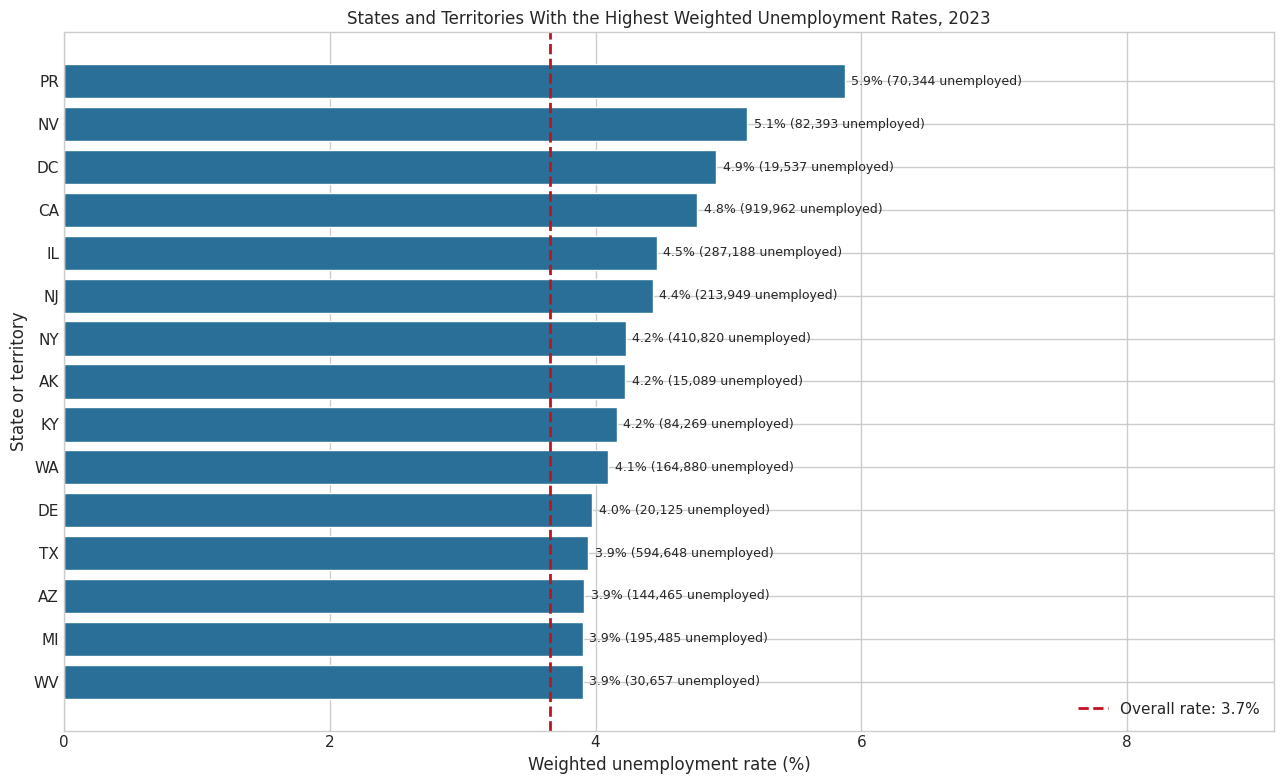

Saved high-level visualization: output/state_unemployment_overview.png

High-level state summary:


,state,total_population,total_labor_force,total_unemployed,weighted_unemployment_rate,counties_included
0,PR,3205691.0,1197474.0,70344.0,5.9,78
1,NV,3194176.0,1602652.0,82393.0,5.1,17
2,DC,678972.0,398251.0,19537.0,4.9,1
3,CA,38965193.0,19308295.0,919962.0,4.8,58
4,IL,12549689.0,6437864.0,287188.0,4.5,102
5,NJ,9290841.0,4829673.0,213949.0,4.4,21
6,KY,4526154.0,2026270.0,84269.0,4.2,120
7,AK,733406.0,357094.0,15089.0,4.2,30
8,NY,19571216.0,9717797.0,410820.0,4.2,62
9,WA,7812880.0,4025767.0,164880.0,4.1,39


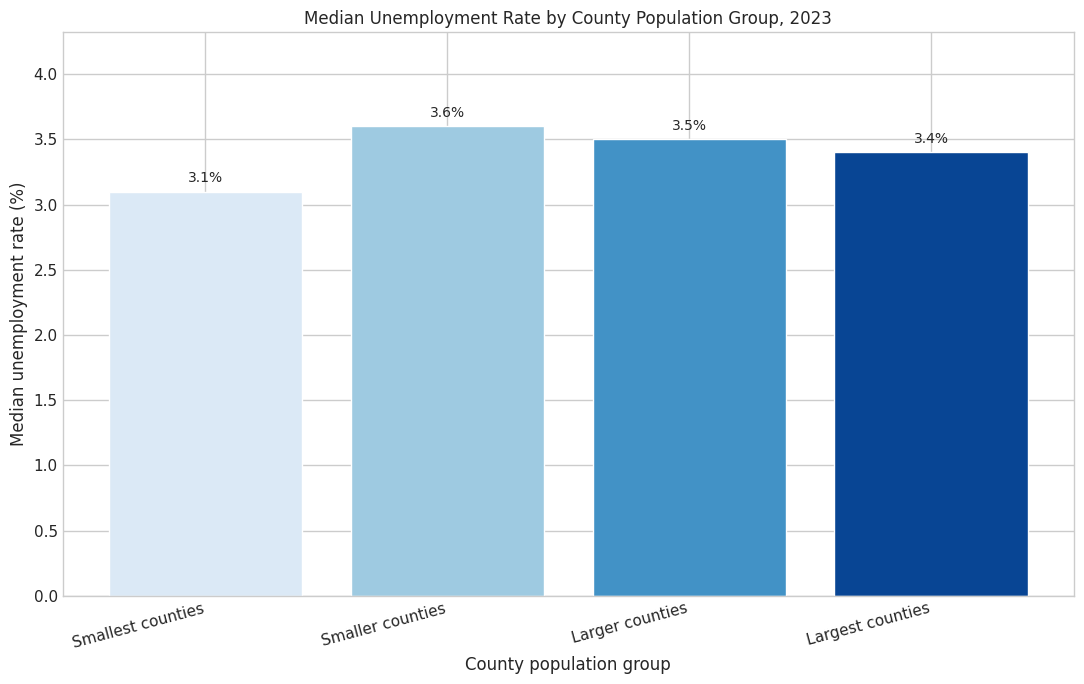

Saved multi-level visualization: output/population_group_comparison.png

Population-group summary:


,population_group,median_population,median_unemployment_rate,average_unemployment_rate,total_unemployed,counties
0,Smallest counties,5856.0,3.1,3.442839,74417.0,803
1,Smaller counties,17442.0,3.6,3.932005,238846.0,803
2,Larger counties,39737.0,3.5,3.775093,562799.0,803
3,Largest counties,169691.0,3.4,3.551059,5189162.0,803


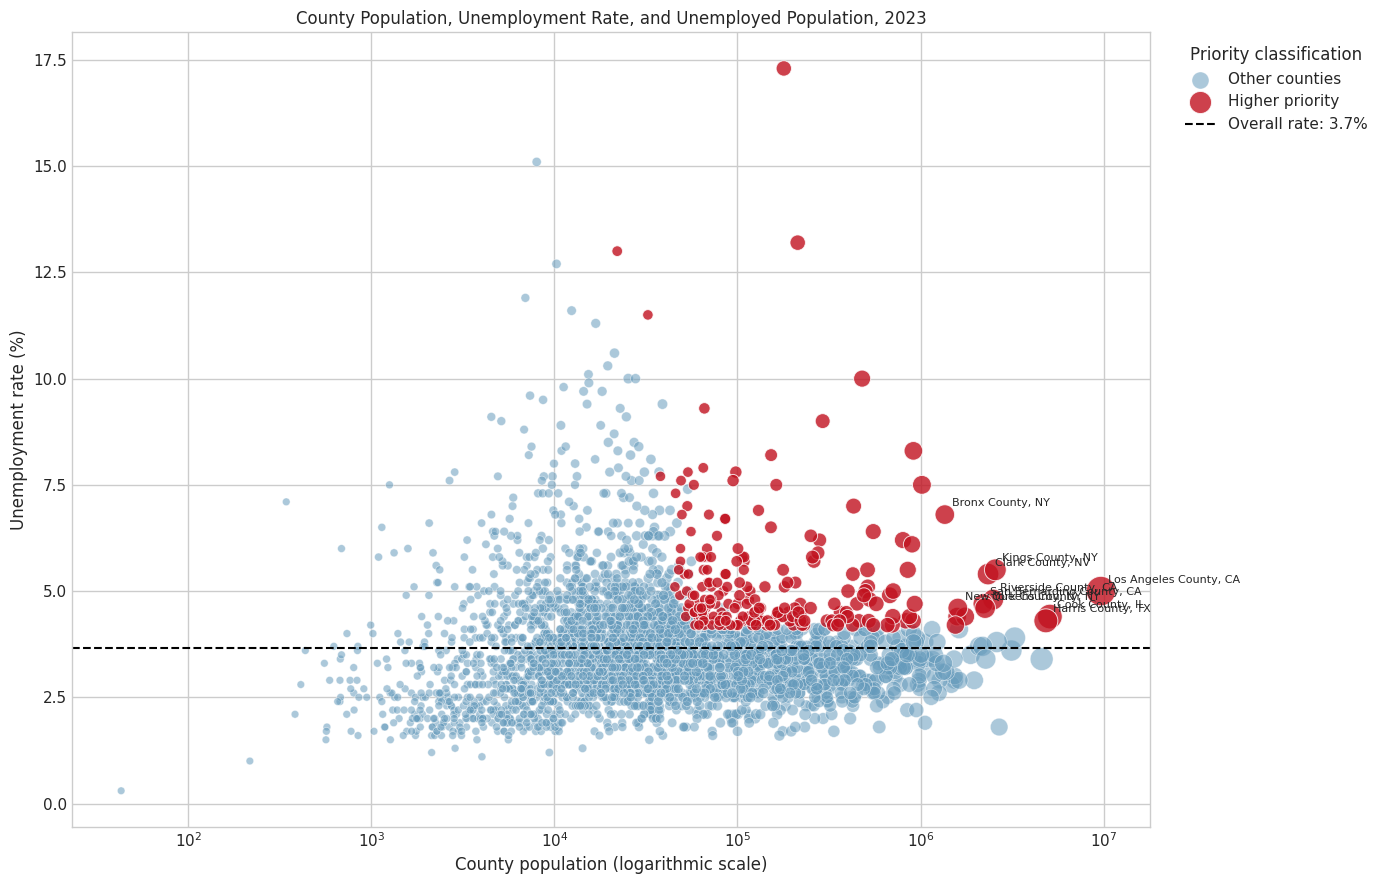

Saved detailed visualization: output/county_unemployment_detail.png


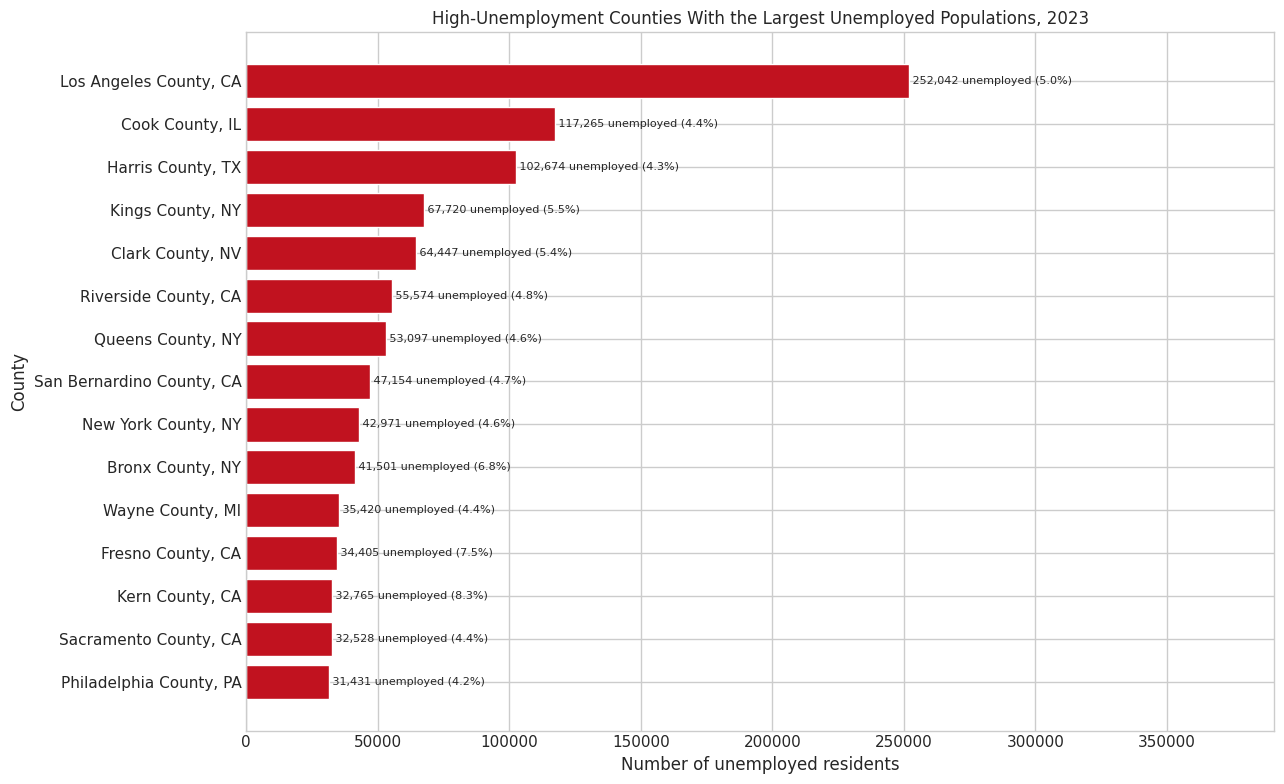

Saved priority visualization: output/workforce_priority_counties.png

Detailed workforce-support priority table:


,county,state,population,labor_force,unemployed,unemployment_rate,population_group
0,Los Angeles County,CA,9663345.0,5015629.0,252042.0,5.0,Largest counties
1,Cook County,IL,5087072.0,2651912.0,117265.0,4.4,Largest counties
2,Harris County,TX,4835125.0,2414902.0,102674.0,4.3,Largest counties
3,Kings County,NY,2561225.0,1225540.0,67720.0,5.5,Largest counties
4,Clark County,NV,2336573.0,1186493.0,64447.0,5.4,Largest counties
5,Riverside County,CA,2492442.0,1157871.0,55574.0,4.8,Largest counties
6,Queens County,NY,2252196.0,1153534.0,53097.0,4.6,Largest counties
7,San Bernardino County,CA,2195611.0,1013665.0,47154.0,4.7,Largest counties
8,New York County,NY,1597451.0,935314.0,42971.0,4.6,Largest counties
9,Bronx County,NY,1356476.0,607911.0,41501.0,6.8,Largest counties



KEY FINDINGS
Analysis year: 2023
Counties included: 3,212
States and territories included: 51
Overall weighted unemployment rate: 3.7%
Correlation between logarithmic county population and unemployment rate: 0.041
Highest weighted state or territory rate: PR at 5.9%
Highest county unemployment rate: Imperial County, CA at 17.3%
County with the largest unemployed population: Los Angeles County, CA with 252,042 unemployed residents
Higher-priority threshold: unemployment rate of at least 4.2% and at least 1,120 unemployed residents


In [33]:
# ============================================================
# DATA VISUALIZATIONS
# ============================================================
# This section creates:
# 1. A high-level state overview for workforce policymakers.
# 2. A population-group comparison using multi-level modeling.
# 3. A detailed county visualization for nonprofit planners.
# 4. A ranked chart of workforce-support priority counties.
# ============================================================


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# Create the output directory.
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


# Use a clean chart style.
plt.style.use("seaborn-v0_8-whitegrid")


# Confirm that preprocessing was completed.
required_columns = [
    "fips",
    "state",
    "county",
    "population",
    "labor_force",
    "employed",
    "unemployed",
    "unemployment_rate",
    "population_group",
    "log10_population"
]

missing_columns = [
    column
    for column in required_columns
    if column not in analysis.columns
]

if missing_columns:
    raise ValueError(
        "The analysis collection is missing these columns: "
        + ", ".join(missing_columns)
        + ". Run the complete preprocessing block first."
    )

if analysis.empty:
    raise ValueError(
        "The analysis collection contains no records."
    )


# Use a fallback title when analysis_year is unavailable.
if "analysis_year" not in globals():
    analysis_year = "Available Year"


print(
    "Records available for visualization:",
    f"{len(analysis):,}"
)

print(
    "States and territories represented:",
    analysis["state"].nunique()
)


# ============================================================
# VISUALIZATION 1
# HIGH-LEVEL STATE OVERVIEW
# Stakeholder: State workforce policymakers
# ============================================================


# Aggregate county records to the state level.
state_summary = (
    analysis
    .groupby("state")
    .agg(
        total_population=(
            "population",
            "sum"
        ),
        total_labor_force=(
            "labor_force",
            "sum"
        ),
        total_employed=(
            "employed",
            "sum"
        ),
        total_unemployed=(
            "unemployed",
            "sum"
        ),
        counties_included=(
            "fips",
            "nunique"
        )
    )
    .reset_index()
)


# Calculate a weighted unemployment rate.
# This prevents small and large counties from
# receiving equal influence in the state result.
state_summary[
    "weighted_unemployment_rate"
] = (
    state_summary["total_unemployed"]
    / state_summary["total_labor_force"]
    * 100
)


# Remove invalid state-level values.
state_summary = state_summary.replace(
    [
        np.inf,
        -np.inf
    ],
    np.nan
)

state_summary = state_summary.dropna(
    subset=[
        "weighted_unemployment_rate"
    ]
)


# Calculate the overall unemployment rate.
overall_unemployment_rate = (
    analysis["unemployed"].sum()
    / analysis["labor_force"].sum()
    * 100
)


# Select the 15 highest-rate states or territories.
top_states = (
    state_summary
    .nlargest(
        min(
            15,
            len(state_summary)
        ),
        "weighted_unemployment_rate"
    )
    .sort_values(
        "weighted_unemployment_rate"
    )
)


# Create the high-level visualization.
plt.figure(figsize=(13, 8))

state_bars = plt.barh(
    top_states["state"],
    top_states[
        "weighted_unemployment_rate"
    ],
    color="#2a6f97",
    edgecolor="white"
)


# Add the overall comparison line.
plt.axvline(
    overall_unemployment_rate,
    color="#c1121f",
    linestyle="--",
    linewidth=2,
    label=(
        f"Overall rate: "
        f"{overall_unemployment_rate:.1f}%"
    )
)


# Add rate and unemployed-count labels.
for bar, rate, unemployed in zip(
    state_bars,
    top_states[
        "weighted_unemployment_rate"
    ],
    top_states["total_unemployed"]
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y()
        + bar.get_height() / 2,
        f"{rate:.1f}% "
        f"({unemployed:,.0f} unemployed)",
        va="center",
        fontsize=9
    )


# Add extra space for the data labels.
if len(top_states) > 0:
    maximum_state_rate = top_states[
        "weighted_unemployment_rate"
    ].max()

    plt.xlim(
        0,
        max(
            1,
            maximum_state_rate * 1.55
        )
    )


plt.title(
    f"States and Territories With the Highest "
    f"Weighted Unemployment Rates, {analysis_year}"
)

plt.xlabel(
    "Weighted unemployment rate (%)"
)

plt.ylabel(
    "State or territory"
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()


# Save the high-level visualization.
state_overview_path = (
    OUTPUT_DIR
    / "state_unemployment_overview.png"
)

plt.savefig(
    state_overview_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved high-level visualization: "
    f"{state_overview_path}"
)


# Display the state-level data.
state_display = top_states[
    [
        "state",
        "total_population",
        "total_labor_force",
        "total_unemployed",
        "weighted_unemployment_rate",
        "counties_included"
    ]
].copy()

state_display[
    "weighted_unemployment_rate"
] = (
    state_display[
        "weighted_unemployment_rate"
    ]
    .round(1)
)

print(
    "\nHigh-level state summary:"
)

display(
    state_display
    .sort_values(
        "weighted_unemployment_rate",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# VISUALIZATION 2
# MULTI-LEVEL POPULATION-GROUP COMPARISON
# ============================================================


# Summarize counties within each population level.
population_group_summary = (
    analysis
    .groupby(
        "population_group",
        observed=True
    )
    .agg(
        median_population=(
            "population",
            "median"
        ),
        median_unemployment_rate=(
            "unemployment_rate",
            "median"
        ),
        average_unemployment_rate=(
            "unemployment_rate",
            "mean"
        ),
        total_unemployed=(
            "unemployed",
            "sum"
        ),
        counties=(
            "fips",
            "nunique"
        )
    )
    .reset_index()
)


# Convert category values to plain text.
population_group_summary[
    "population_group"
] = (
    population_group_summary[
        "population_group"
    ]
    .astype(str)
)


# Generate compatible colors without using
# newer Seaborn plotting arguments.
base_colors = [
    "#dbe9f6",
    "#9ecae1",
    "#4292c6",
    "#084594"
]

group_colors = [
    base_colors[index % len(base_colors)]
    for index in range(
        len(population_group_summary)
    )
]


plt.figure(figsize=(11, 7))

group_bars = plt.bar(
    population_group_summary[
        "population_group"
    ],
    population_group_summary[
        "median_unemployment_rate"
    ],
    color=group_colors,
    edgecolor="white"
)


# Add unemployment-rate labels.
for bar in group_bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        height + 0.05,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )


if len(population_group_summary) > 0:
    maximum_group_rate = population_group_summary[
        "median_unemployment_rate"
    ].max()

    plt.ylim(
        0,
        max(
            1,
            maximum_group_rate * 1.20
        )
    )


plt.title(
    f"Median Unemployment Rate by "
    f"County Population Group, {analysis_year}"
)

plt.xlabel(
    "County population group"
)

plt.ylabel(
    "Median unemployment rate (%)"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()


# Save the population-group visualization.
population_group_path = (
    OUTPUT_DIR
    / "population_group_comparison.png"
)

plt.savefig(
    population_group_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved multi-level visualization: "
    f"{population_group_path}"
)


print(
    "\nPopulation-group summary:"
)

display(
    population_group_summary
)


# ============================================================
# IDENTIFY HIGHER-PRIORITY COUNTIES
# Stakeholder: Nonprofit workforce-development planners
# ============================================================


# Calculate upper-quartile thresholds.
rate_threshold = (
    analysis["unemployment_rate"]
    .quantile(0.75)
)

unemployed_threshold = (
    analysis["unemployed"]
    .quantile(0.75)
)


# A higher-priority county must be in the upper
# quartile for both unemployment rate and number
# of unemployed residents.
analysis["priority_status"] = np.where(
    (
        analysis["unemployment_rate"]
        >= rate_threshold
    )
    &
    (
        analysis["unemployed"]
        >= unemployed_threshold
    ),
    "Higher priority",
    "Other counties"
)


# Select counties for detailed review.
priority_counties = (
    analysis.loc[
        analysis["priority_status"]
        == "Higher priority"
    ]
    .nlargest(
        min(
            15,
            len(analysis)
        ),
        "unemployed"
    )
    .copy()
)


# Provide a fallback for very small samples.
if priority_counties.empty:
    priority_counties = (
        analysis
        .nlargest(
            min(
                15,
                len(analysis)
            ),
            "unemployment_rate"
        )
        .copy()
    )


# ============================================================
# VISUALIZATION 3
# DETAILED COUNTY SCATTERPLOT
# ============================================================


# Scale marker sizes using the number of
# unemployed residents.
unemployed_square_root = np.sqrt(
    analysis["unemployed"]
    .clip(lower=0)
)

minimum_size_value = (
    unemployed_square_root.min()
)

maximum_size_value = (
    unemployed_square_root.max()
)


if maximum_size_value > minimum_size_value:
    analysis["marker_size"] = (
        30
        + 420
        * (
            unemployed_square_root
            - minimum_size_value
        )
        / (
            maximum_size_value
            - minimum_size_value
        )
    )

else:
    analysis["marker_size"] = 100


plt.figure(figsize=(14, 9))


# Plot ordinary counties.
other_counties = analysis.loc[
    analysis["priority_status"]
    == "Other counties"
]

if not other_counties.empty:
    plt.scatter(
        other_counties["population"],
        other_counties[
            "unemployment_rate"
        ],
        s=other_counties["marker_size"],
        color="#669bbc",
        alpha=0.55,
        edgecolors="white",
        linewidths=0.5,
        label="Other counties"
    )


# Plot higher-priority counties.
higher_priority_counties = analysis.loc[
    analysis["priority_status"]
    == "Higher priority"
]

if not higher_priority_counties.empty:
    plt.scatter(
        higher_priority_counties[
            "population"
        ],
        higher_priority_counties[
            "unemployment_rate"
        ],
        s=higher_priority_counties[
            "marker_size"
        ],
        color="#c1121f",
        alpha=0.80,
        edgecolors="white",
        linewidths=0.7,
        label="Higher priority"
    )


# Add the overall unemployment-rate benchmark.
plt.axhline(
    overall_unemployment_rate,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall rate: "
        f"{overall_unemployment_rate:.1f}%"
    )
)


# Label up to 10 priority counties.
label_counties = (
    priority_counties
    .nlargest(
        min(
            10,
            len(priority_counties)
        ),
        "unemployed"
    )
)

for _, row in label_counties.iterrows():
    plt.annotate(
        f"{row['county']}, "
        f"{row['state']}",
        (
            row["population"],
            row["unemployment_rate"]
        ),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=8
    )


# Population values are right-skewed.
plt.xscale("log")

plt.title(
    f"County Population, Unemployment Rate, "
    f"and Unemployed Population, {analysis_year}"
)

plt.xlabel(
    "County population "
    "(logarithmic scale)"
)

plt.ylabel(
    "Unemployment rate (%)"
)

plt.legend(
    title=(
        "Priority classification"
    ),
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()


# Save the detailed visualization.
county_detail_path = (
    OUTPUT_DIR
    / "county_unemployment_detail.png"
)

plt.savefig(
    county_detail_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved detailed visualization: "
    f"{county_detail_path}"
)


# ============================================================
# VISUALIZATION 4
# DETAILED PRIORITY-COUNTY RANKING
# ============================================================


priority_chart = (
    priority_counties
    .nlargest(
        min(
            15,
            len(priority_counties)
        ),
        "unemployed"
    )
    .sort_values(
        "unemployed"
    )
    .copy()
)


# Combine county and state names.
priority_chart["county_label"] = (
    priority_chart["county"]
    + ", "
    + priority_chart["state"]
)


plt.figure(figsize=(13, 8))

priority_bars = plt.barh(
    priority_chart["county_label"],
    priority_chart["unemployed"],
    color="#c1121f",
    edgecolor="white"
)


# Add unemployed counts and unemployment rates.
for bar, unemployed, rate in zip(
    priority_bars,
    priority_chart["unemployed"],
    priority_chart[
        "unemployment_rate"
    ]
):
    plt.text(
        bar.get_width(),
        bar.get_y()
        + bar.get_height() / 2,
        f" {unemployed:,.0f} unemployed "
        f"({rate:.1f}%)",
        va="center",
        fontsize=8
    )


# Add additional horizontal space for labels.
if len(priority_chart) > 0:
    maximum_unemployed = priority_chart[
        "unemployed"
    ].max()

    plt.xlim(
        0,
        max(
            1,
            maximum_unemployed * 1.55
        )
    )


plt.title(
    f"High-Unemployment Counties With the "
    f"Largest Unemployed Populations, {analysis_year}"
)

plt.xlabel(
    "Number of unemployed residents"
)

plt.ylabel(
    "County"
)

plt.tight_layout()


# Save the priority visualization.
priority_path = (
    OUTPUT_DIR
    / "workforce_priority_counties.png"
)

plt.savefig(
    priority_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved priority visualization: "
    f"{priority_path}"
)


# ============================================================
# DETAILED PRIORITY TABLE
# ============================================================


priority_display = priority_chart[
    [
        "county",
        "state",
        "population",
        "labor_force",
        "unemployed",
        "unemployment_rate",
        "population_group"
    ]
].copy()

priority_display[
    "unemployment_rate"
] = (
    priority_display[
        "unemployment_rate"
    ]
    .round(1)
)

print(
    "\nDetailed workforce-support priority table:"
)

display(
    priority_display
    .sort_values(
        "unemployed",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# KEY FINDINGS
# ============================================================


# Calculate the association between county population
# and unemployment rate.
if len(analysis) > 1:
    population_rate_correlation = (
        analysis[
            [
                "log10_population",
                "unemployment_rate"
            ]
        ]
        .corr()
        .iloc[0, 1]
    )

else:
    population_rate_correlation = np.nan


# Identify the highest state-level rate.
highest_state = (
    state_summary
    .nlargest(
        1,
        "weighted_unemployment_rate"
    )
    .iloc[0]
)


# Identify the highest county unemployment rate.
highest_rate_county = (
    analysis
    .nlargest(
        1,
        "unemployment_rate"
    )
    .iloc[0]
)


# Identify the largest unemployed population.
largest_unemployed_county = (
    analysis
    .nlargest(
        1,
        "unemployed"
    )
    .iloc[0]
)


print(
    "\nKEY FINDINGS"
)

print(
    "Analysis year:",
    analysis_year
)

print(
    "Counties included:",
    f"{len(analysis):,}"
)

print(
    "States and territories included:",
    analysis["state"].nunique()
)

print(
    "Overall weighted unemployment rate:",
    f"{overall_unemployment_rate:.1f}%"
)

if pd.notna(
    population_rate_correlation
):
    print(
        "Correlation between logarithmic county "
        "population and unemployment rate:",
        f"{population_rate_correlation:.3f}"
    )

else:
    print(
        "Population and unemployment correlation "
        "could not be calculated because the "
        "collection contains only one record."
    )

print(
    "Highest weighted state or territory rate:",
    f"{highest_state['state']} at "
    f"{highest_state['weighted_unemployment_rate']:.1f}%"
)

print(
    "Highest county unemployment rate:",
    f"{highest_rate_county['county']}, "
    f"{highest_rate_county['state']} at "
    f"{highest_rate_county['unemployment_rate']:.1f}%"
)

print(
    "County with the largest unemployed population:",
    f"{largest_unemployed_county['county']}, "
    f"{largest_unemployed_county['state']} with "
    f"{largest_unemployed_county['unemployed']:,.0f} "
    f"unemployed residents"
)

print(
    "Higher-priority threshold:",
    f"unemployment rate of at least "
    f"{rate_threshold:.1f}% and at least "
    f"{unemployed_threshold:,.0f} unemployed residents"
)